# **Project Name -** Aerial Object Classification & Detection

# **GitHub Link -**

# **Problem Statement** -
This project aims to develop a deep learning-based solution that can classify aerial images into two categories — Bird or Drone — and optionally perform object detection to locate and label these objects in real-world scenes.

The solution will help in security surveillance, wildlife protection, and airspace safety where accurate identification between drones and birds is critical. The project involves building a Custom CNN classification model, leveraging transfer learning,

# **Workflow** -

## 1. Load Dataset

In [ ]:
# Uploading dataset

from google.colab import files
uploaded = files.upload()

Saving train.zip to train.zip
Saving valid.zip to valid.zip
Saving test.zip to test.zip


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'valid.zip', 'test.zip', 'train.zip', 'sample_data']


In [ ]:
# Extract All ZIPs

import zipfile

zip_files = ["train.zip", "valid.zip", "test.zip"]

for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("/content/")

print("Extraction complete!")

Extraction complete!


In [ ]:
# Check Final Structure

print(os.listdir("/content"))

['.config', 'valid.zip', 'test.zip', 'train.zip', 'test', 'valid', 'train', 'sample_data']


In [ ]:
print(os.listdir("/content/train"))

['bird', 'drone']


## 2. Exploratory Data Analysis (EDA)

### 1. Count Images Per Class

In [ ]:
import os

dataset_path = "/content/train"
class_counts = {}

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

print(class_counts)

{'bird': 1414, 'drone': 1248}


### 2. Visualize Class Distribution

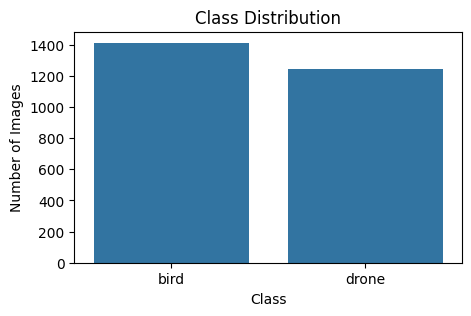

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

### 3. Show Sample Images

In [ ]:
import random
from PIL import Image

def show_images(class_name, num_images=5):
    folder = os.path.join(dataset_path, class_name)
    images = random.sample(os.listdir(folder), num_images)

    plt.figure(figsize=(12,5))

    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path).resize((224, 224))

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.show()

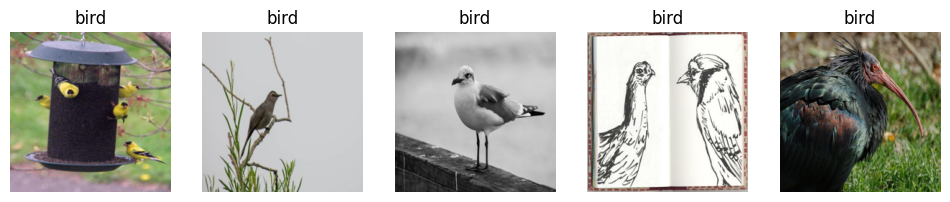

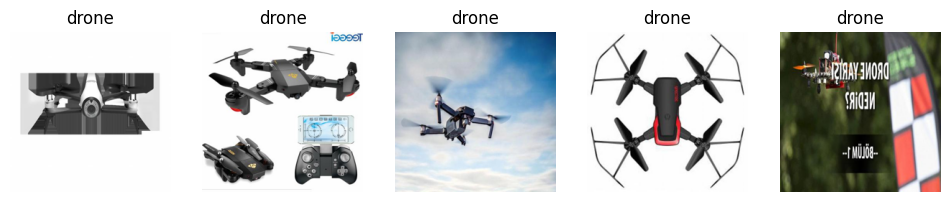

In [ ]:
show_images("bird")
show_images("drone")

## 3. Data Augmentation

### 1. Check Image Shape

In [ ]:
import numpy as np

img_path = os.path.join(dataset_path, "bird", os.listdir(os.path.join(dataset_path, "bird"))[0])
img = Image.open(img_path)
img_array = np.array(img)

print("Image shape:", img_array.shape)

Image shape: (416, 416, 3)


In [ ]:
print("Total images:", sum(class_counts.values()))

Total images: 2662


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_path = "/content/train"
valid_path = "/content/valid"
test_path = "/content/test"

### 2. Handling Generators

In [ ]:
#Training Generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalization
    rotation_range=20,       # rotate images
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
#Validation Generator (NO augmentation)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#Test Generator (NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

### 2. Load Data Using flow_from_directory

Training Data

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.


Validation Data

In [ ]:
valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 442 images belonging to 2 classes.


Test Data

In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # IMPORTANT for evaluation later
)

Found 215 images belonging to 2 classes.


### 3. Check Class Mapping

In [ ]:
print(train_generator.class_indices)

{'bird': 0, 'drone': 1}


Check One Batch

In [ ]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Labels shape: (32,)


### 4. Visualize Augmented Images

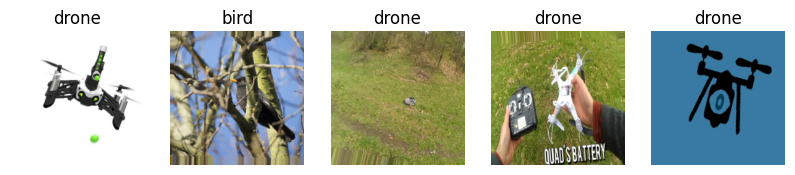

In [ ]:
import matplotlib.pyplot as plt

class_labels = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])

    label = int(labels[i])
    plt.title(class_labels[label])  # shows bird/drone

    plt.axis('off')

plt.show()

### Insight & Observations
The training dataset is larger to allow the model to learn patterns effectively, while validation and test sets are smaller and used only for unbiased evaluation to avoid overfitting and data leakage.

## 4. Model Building

### 1. CNN Model

In [ ]:
# Import Liabraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#### 1. Build Model

In [ ]:
model = Sequential([

    Input(shape=(224,224,3)),   # ✅ Proper way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

#### 2. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### 3. Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

#### 4. Train Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 361s 4s/step - accuracy: 0.5793 - loss: 0.7516 - val_accuracy: 0.7149 - val_loss: 0.5443
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 363s 4s/step - accuracy: 0.7141 - loss: 0.5636 - val_accuracy: 0.7443 - val_loss: 0.5157
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.7603 - loss: 0.4970 - val_accuracy: 0.7624 - val_loss: 0.4720
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.7761 - loss: 0.4737 - val_accuracy: 0.7851 - val_loss: 0.4814
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.7953 - loss: 0.4462 - val_accuracy: 0.7647 - val_loss: 0.4909
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.7994 - loss: 0.4209 - val_accuracy: 0.6742 - val_loss: 0.7948
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.7919 - loss: 0.4433 - val_accuracy: 0.7828 - val_loss: 0.4900
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.8178 - loss: 0.4025 - val_accuracy: 0.7851 - v

#### 5. Plot Accuracy & Loss

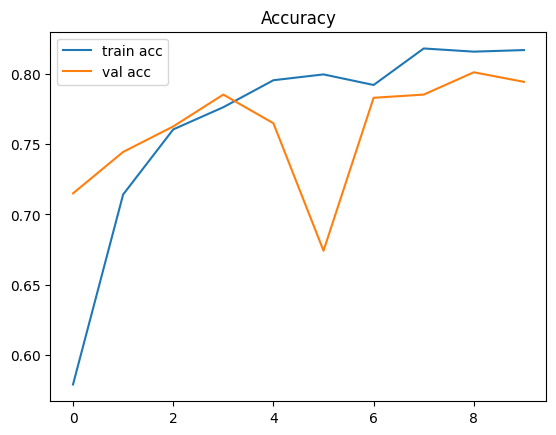

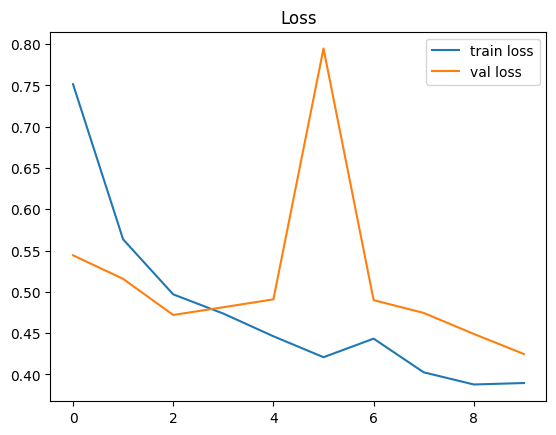

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

### 2. CNN Model 2 - Improved version

#### 1. Build Model

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

cnn_v2 = Sequential([

    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

#### 2. Compile Model

In [ ]:
cnn_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### 3. Model Summary

In [ ]:
cnn_v2.summary()

#### 4. Train Model

In [ ]:
history_v2 = cnn_v2.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.5582 - loss: 0.6798 - val_accuracy: 0.5973 - val_loss: 0.6330
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.6634 - loss: 0.6209 - val_accuracy: 0.6765 - val_loss: 0.5763
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.7074 - loss: 0.5722 - val_accuracy: 0.6900 - val_loss: 0.5702
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.7359 - loss: 0.5449 - val_accuracy: 0.7149 - val_loss: 0.5700
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.7419 - loss: 0.5262 - val_accuracy: 0.7240 - val_loss: 0.5428
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 0.7648 - loss: 0.5001 - val_accuracy: 0.7376 - val_loss: 0.5088
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.7633 - loss: 0.4935 - val_accuracy: 0.7172 - val_loss: 0.5402
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.7663 - loss: 0.4895 - val_accuracy: 0.7308 - v

#### 5. Plot Accuracy & Loss

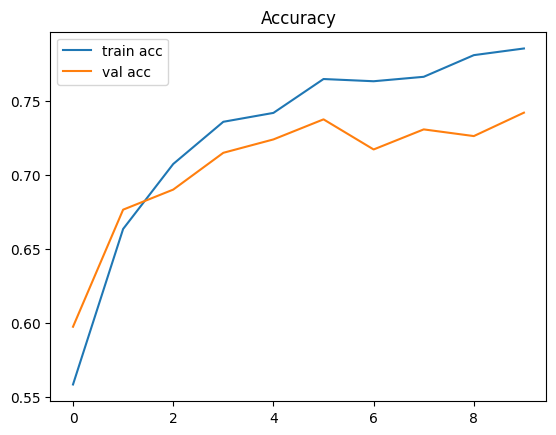

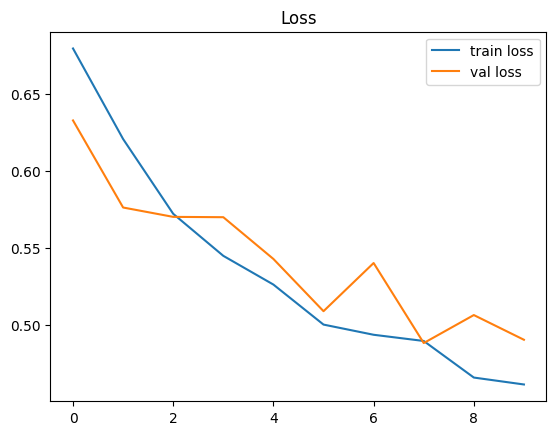

In [ ]:

# Accuracy
plt.plot(history_v2.history['accuracy'], label='train acc')
plt.plot(history_v2.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history_v2.history['loss'], label='train loss')
plt.plot(history_v2.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

I experimented with reducing model complexity using GlobalAveragePooling, which improved efficiency but slightly reduced accuracy. This helped me understand the trade-off between model capacity and generalization.

### 3. Transfer Learning (MobileNetV2)

#### 1. Import Liabraries

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

#### 2. Load Pretrained Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',      # pretrained weights
    include_top=False,       # remove original classifier
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 3. Freeze Base Model

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

#### 4. Build Final Model

In [ ]:
model_tl = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

#### 5. Compile Model

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### 6. Model Summary

In [ ]:
model_tl.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### 7. Train Model

In [ ]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5   # fewer epochs needed
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9076 - loss: 0.2197 - val_accuracy: 0.9615 - val_loss: 0.0973
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9621 - loss: 0.0953 - val_accuracy: 0.9706 - val_loss: 0.0835
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9684 - loss: 0.0793 - val_accuracy: 0.9774 - val_loss: 0.0826
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9696 - loss: 0.0693 - val_accuracy: 0.9729 - val_loss: 0.0778
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9786 - loss: 0.0617 - val_accuracy: 0.9683 - val_loss: 0.0841


#### 8. Plot Accuracy & Loss

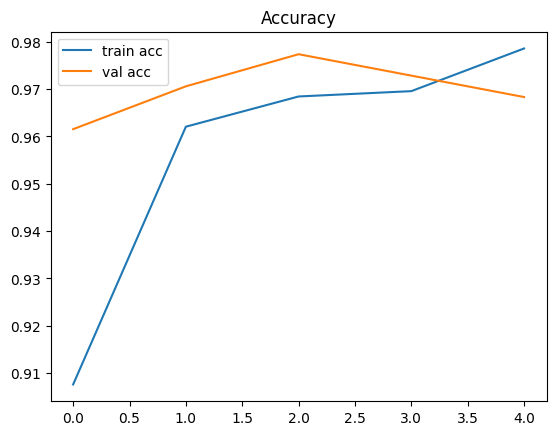

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_tl.history['accuracy'], label='train acc')
plt.plot(history_tl.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

## 4. Model Evaluation

### 1. Evaluate on Test Data

In [ ]:
test_loss, test_acc = model_tl.evaluate(test_generator)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9721 - loss: 0.0786
Test Accuracy: 0.9720930457115173


### 2. Predictions

In [ ]:
import numpy as np

preds = model_tl.predict(test_generator)
pred_classes = (preds > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


### 3. Confusion Matrix

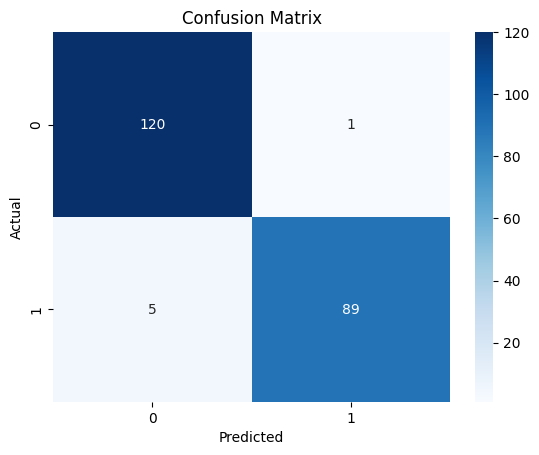

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_generator.classes, pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 4. Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_generator.classes,
    pred_classes,
    target_names=['bird', 'drone']
))

              precision    recall  f1-score   support

        bird       0.96      0.99      0.98       121
       drone       0.99      0.95      0.97        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



System can reliably detect drones in restricted airspace

 Very low false positives → avoids unnecessary alerts

 Very low false negatives → improves security

## 5. Model Comparison

In this project, three models were tested:
1. CNN Model Version 1
2. CNN Model Version 2
3. Transfer Learning Model (MobileNetV2)

The models were compared based on accuracy, training time, and overall performance.

| Model | Validation Accuracy | Parameters | Training Time | Remarks |
|------|----------------------|-----------|--------------|--------|
| CNN V1 | ~79% | High (11M+) | Slow | Better than CNN V2 |
| CNN V2 | ~74% | Moderate | Moderate | Lower accuracy |
| MobileNetV2 | ~97% | Low Trainable Params | Fast | Best model |

Initially, I expected the custom CNN to perform best, but transfer learning gave much better results. It gave the highest accuracy and faster training performance.Therefore, it was selected as the final model for deployment.

## 6. Insights and Observations

- Transfer learning model (MobileNetV2) performed much better than custom CNN models.
- Higher number of parameters did not guarantee better accuracy.
- Data augmentation helped improve model generalization by creating varied    versions of training images such as rotation, flipping, zoom, and brightness changes
- Custom CNN models required more training time and tuning.
- Pretrained models saved time and gave faster results.
- Working with image data was different from structured datasets and required new preprocessing steps.

## 7. Conclusion

In this project, I tested different models for Bird vs Drone image classification.  
The transfer learning model (MobileNetV2) performed best and achieved around 97% accuracy.

This project gave me my first hands-on experience with image data and helped me learn deep learning concepts in a practical way.

## 8. Save model and Download

In [ ]:
model_tl.save("bird_drone_model.keras")

In [ ]:
from google.colab import files
files.download("bird_drone_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# Load model (optional if already in memory)
model = tf.keras.models.load_model("bird_drone_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp35l6v7ym'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136152162781520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162782288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162782096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162782864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162781136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162782480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162782672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162780560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136152162783824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1361521627832

In [ ]:
from google.colab import files
files.download("model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>